In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

data=pd.read_excel("2023_Taiwan_Cleaned.xlsx",sheet_name="Data")

#計算每位員工的平均薪資
data["avgsalary"] = data["TotalSalary"] / data["Employees"]
# 樣本過濾: 排除缺失值與極端值
mask = ((data['Employees'] > 0) &
        (data['TotalSalary'] > 0) &
        (data['TotalAssets'] > 0) &
        (data['avgsalary'] >= 350000))
data = data[mask].copy()

# 計算每個產業的公司家數
sector_count = data["SectorName"].value_counts()
# 保留公司家數 >= 15 的產業
valid_sectors = sector_count[sector_count >= 15].index
# 篩選資料
filtered_data = data[data["SectorName"].isin(valid_sectors)]
# 計算各產業平均薪資的中位數
sector_salary = (
    filtered_data
    .groupby("SectorName")["avgsalary"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
# 整體產業員工平均薪資的中位數
median = filtered_data["avgsalary"].median()

In [3]:
# 進行Kruskal-Wallis檢定，檢驗各產業薪資是否有顯著差異
import scipy.stats as stats
groups = [
    filtered_data[filtered_data["SectorName"] == s]["avgsalary"]
    for s in valid_sectors
]
h, p = stats.kruskal(*groups)

# p 值 < 0.001
p_str = "< 0.001" if p < 0.001 else f"= {p:.4f}"

print(f"Kruskal-Wallis H = {h:.2f}, p {p_str}")
if p < 0.05:
    print("→ 不同產業的薪資存在顯著差異")
else:
    print("→ 沒有顯著差異")

Kruskal-Wallis H = 247.80, p < 0.001
→ 不同產業的薪資存在顯著差異


In [4]:
#顯示所有產業的平均員工薪資中位數
print("產業中位數:",median)

產業中位數: 715918.5778587505


/var/folders/h6/1vhftsfd43gbs631lgbbfz980000gn/T/ipykernel_86075/2304932444.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot( data=sector_salary,y="SectorName",x="avgsalary",palette=colors)


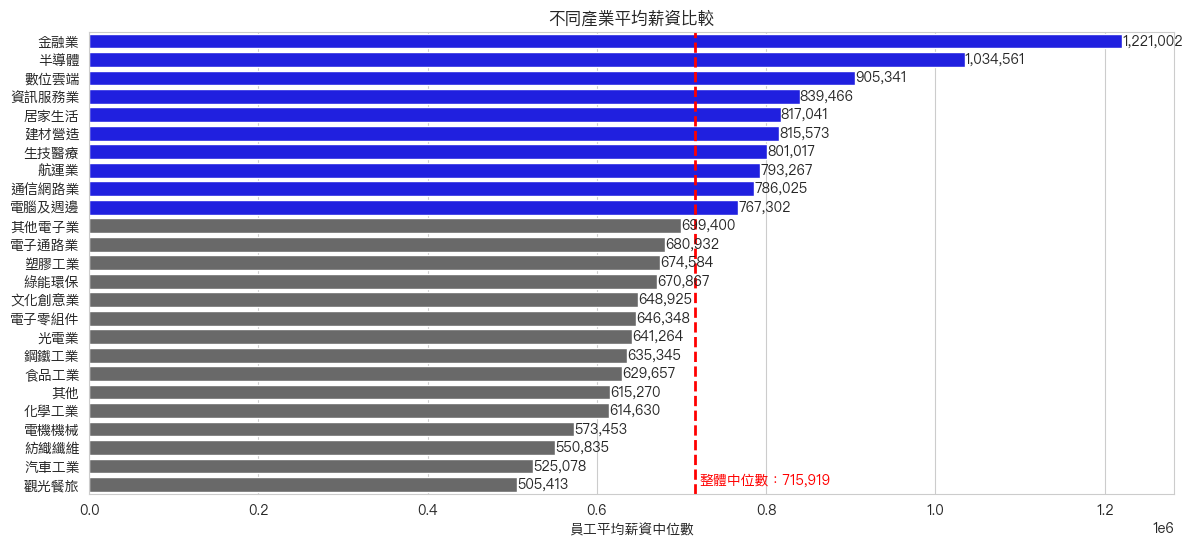

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定 seaborn 主題
sns.set_style("whitegrid")
#避免中文顯示成方框
plt.rcParams["font.sans-serif"] = ["PingFang HK"]


plt.figure(figsize=(14,6))

#根據是否高於整體中位數設定顏色
colors = ["b" if x >= median else "dimgrey"
    for x in sector_salary["avgsalary"]]

# seaborn 長條圖
ax = sns.barplot( data=sector_salary,y="SectorName",x="avgsalary",palette=colors)

# 整體中位數虛線
ax.axvline(median,color="red",linestyle="--",linewidth=2)

# 顯示中位數文字
ax.text(median + 5000,len(sector_salary)-1,f"整體中位數：{median:,.0f}",color="red")

# 座標與標題
ax.set_xlabel("員工平均薪資中位數")
ax.set_ylabel("")
ax.set_title("不同產業平均薪資比較")

# 顯示 bar 數值（千分位）
for i in ax.containers:
    labels = [f"{v:,.0f}" for v in i.datavalues]
    ax.bar_label(i, labels=labels)

plt.savefig('不同產業平均薪資比較.jpg')
plt.show()

In [6]:
#3員工平均薪資較高的公司，是否伴隨著高生產力（人均產值）？
data["GrossProfit_per_employee"] = (data["GrossProfit"] / data["Employees"])
filtered_data = data[data["SectorName"].isin(valid_sectors)].copy()
# 對變數進行log轉換（壓縮極端值、降低偏態）
gp = filtered_data["GrossProfit_per_employee"]
filtered_data["log_salary"] = np.log(filtered_data["avgsalary"])
filtered_data["log_grossprofit"] = np.log(gp.where(gp > 0))
#計算log後的相關係數
filtered_data[["log_salary", "log_grossprofit"]].corr()

,log_salary,log_grossprofit
log_salary,1.000000,0.438329
log_grossprofit,0.438329,1.000000


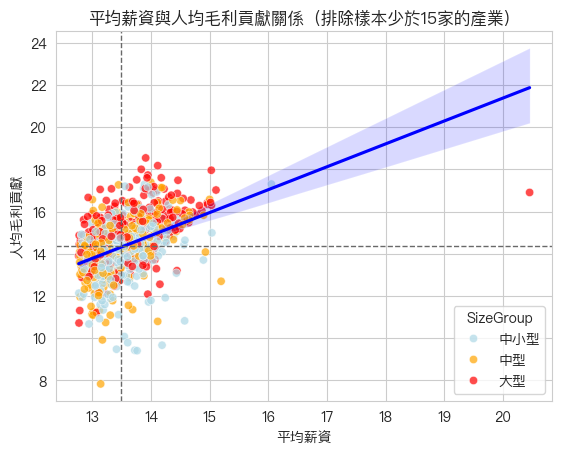

In [7]:
# 依照規模四分位分組
filtered_data["SizeGroup"] = pd.qcut(
    filtered_data["TotalAssets"],3,
    labels=["中小型", "中型", "大型"]
)
# 用中位數作為象限分隔線
x_median = filtered_data["log_salary"].median()
y_median = filtered_data["log_grossprofit"].median()

#畫散點圖與修改顏色
sns.scatterplot(
    x="log_salary",
    y="log_grossprofit",
    hue="SizeGroup",
    data=filtered_data,
    palette={"中小型": "lightblue","中型": "orange","大型": "red"},
    alpha=0.7
)

# 回歸線
sns.regplot(
    x="log_salary",
    y="log_grossprofit",
    data=filtered_data,
    scatter=False,   # 不重複畫點
    line_kws={"color":"blue"}
)
# 象限分隔線（中位數）
plt.axvline(x_median, color="dimgrey", linestyle="--", linewidth=1)
plt.axhline(y_median, color="dimgrey", linestyle="--", linewidth=1)

plt.xlabel("平均薪資")
plt.ylabel("人均毛利貢獻")
plt.title("平均薪資與人均毛利貢獻關係（排除樣本少於15家的產業）")
plt.savefig('平均薪資與人均毛利貢獻關係.jpg')
plt.show()


In [8]:
# 計算每個產業的中位數
sector_summary = (
    filtered_data
    .groupby("SectorName")
    .agg(
        median_salary=("log_salary", "median"),
        median_prod=("log_grossprofit", "median"),
        n=("log_salary", "count")
    )
    .reset_index()
)

# 用全體中位數作為象限分隔
x_median = filtered_data["log_salary"].median()
y_median = filtered_data["log_grossprofit"].median()

# 判斷每個產業屬於哪個象限
def get_quadrant(row):
    if row["median_salary"] >= x_median and row["median_prod"] >= y_median:
        return "高薪高產值"
    elif row["median_salary"] < x_median and row["median_prod"] >= y_median:
        return "低薪高產值"
    elif row["median_salary"] < x_median and row["median_prod"] < y_median:
        return "低薪低產值"
    else:
        return "高薪低產值"
sector_summary["quadrant"] = sector_summary.apply(get_quadrant, axis=1)

# 顯示每個象限的產業
for q in ["高薪高產值", "低薪高產值", "高薪低產值", "低薪低產值"]:
    sectors = sector_summary[sector_summary["quadrant"] == q]["SectorName"].tolist()
    print(f"\n【{q}】共 {len(sectors)} 個產業")
    for s in sectors:
        print(f"   • {s}")


【高薪高產值】共 7 個產業
   • 半導體
   • 居家生活
   • 建材營造
   • 數位雲端
   • 生技醫療
   • 金融業
   • 電腦及週邊

【低薪高產值】共 3 個產業
   • 化學工業
   • 電子通路業
   • 食品工業

【高薪低產值】共 3 個產業
   • 航運業
   • 資訊服務業
   • 通信網路業

【低薪低產值】共 12 個產業
   • 光電業
   • 其他
   • 其他電子業
   • 塑膠工業
   • 文化創意業
   • 汽車工業
   • 紡織纖維
   • 綠能環保
   • 觀光餐旅
   • 鋼鐵工業
   • 電子零組件
   • 電機機械
